In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def align_pointclouds(XYZ_ref, XYZ_est, ind_to_align):
    """
    Align a point cloud with a reference one, using the described in the following communication :
    'A solution for the best rotation to relate two sets of vectors', Kabsch, Acta Cryst 1976.
    Inputs : 
    - XYZ_ref : (Nref,3) array, lines are reference points to align.
    - XYZ_est : (Nest,3) array, lines are positions to align (Nest>=Nref).
    - ind_to_align : (Nref,1) array, indices corresponding to the points in XYZ_est to align with XYZ_ref.
    Outputs : 
    - XYZ_ref_centered : (Nref, 3) array, lines are centered positions of the reference points.
    - XYZ_est_aligned : (Nest, 3) array, lines are centered positions of the aligned points.
    """
    # Start by centering point clouds
    center_ref = XYZ_ref.mean(axis = 0)
    XYZ_ref_centered = XYZ_ref - center_ref

    center_est = XYZ_est[ind_to_align,:].mean(axis = 0)
    XYZ_est_centered = XYZ_est - center_est

    # Compute covariance between point clouds
    S_ref_est = XYZ_est_centered[ind_to_align,:].T @ XYZ_ref_centered
    
    # Perform covariance's svd
    u, s, v = np.linalg.svd(S_ref_est)
    # find rotation's sign
    e = np.eye(3)
    e[-1, -1] = np.sign(s.prod())
    # compute Rotation matrix (adjust sign with e)
    rotation = (v.T @ e @ u.T).T
    # Perform rotation on centered cloud to align
    XYZ_est_aligned = XYZ_est_centered @ rotation
    
    return XYZ_ref_centered, XYZ_est_aligned

In [3]:
import numpy as np
from scipy.spatial.transform import Rotation as R_scipy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call half the max range the plot radius.
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])
    
    # Try to set box aspect to be cubic if supported (Matplotlib 3.3+)
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect((1, 1, 1))

def plotToAlignAndAligned(xyz_toalign, xyz_aligned):
    fig = plt.figure(figsize=(14, 6))
    num_chunks = (xyz_toalign.shape[0]) // 8
    # Define colors for chunks to see alignment better
    cmap = cm.get_cmap('tab20', num_chunks)

    # Plot Original
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title("Before Rotation")
    

    # Plot chunks with colors
    for i in range(num_chunks):
        c_mics = xyz_toalign[i*8 : (i+1)*8, :]
        ax1.scatter(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), marker='o', s=20)
        # Draw line through chunk to show direction
        # Simple line between start and end of chunk for visualization
        ax1.plot(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), alpha=0.5)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    set_axes_equal(ax1)

    # Plot Rotated
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("After Rotation")

    for i in range(num_chunks):
        c_mics = xyz_aligned[i*8 : (i+1)*8, :]
        ax2.scatter(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), marker='o', s=20)
        ax2.plot(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), alpha=0.5)

    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    set_axes_equal(ax2)

    plt.tight_layout()
    plt.show()

C:\Users\froll\AppData\Local\Temp\ipykernel_17036\3903632388.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_chunks)


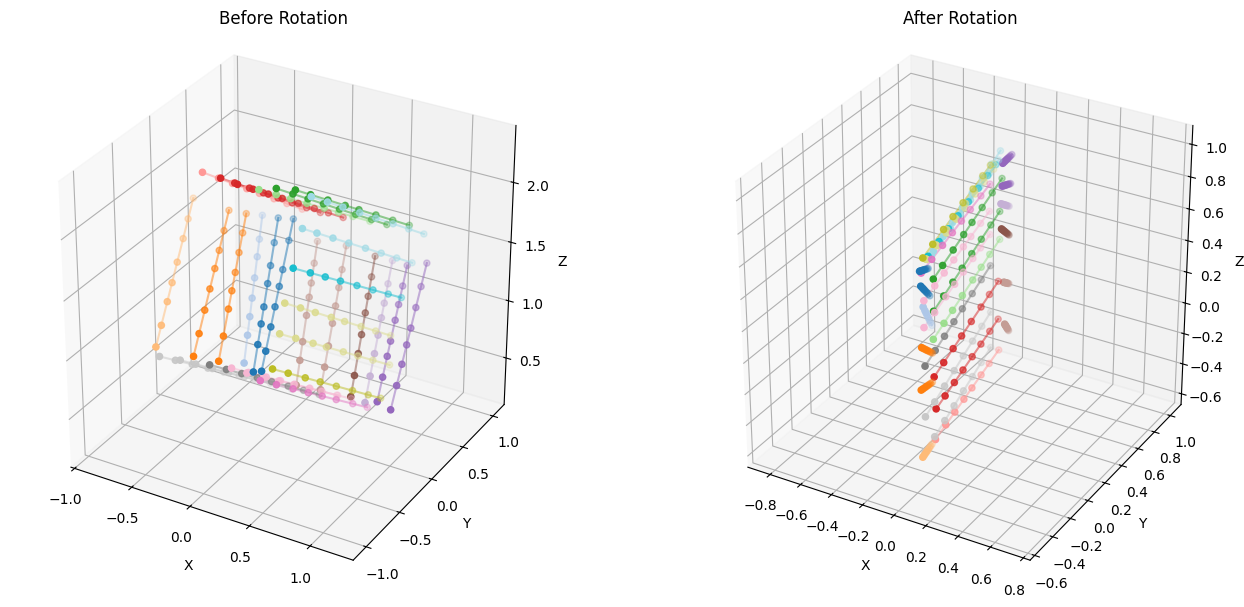

In [6]:
XYZ = np.load("XYZCETIMrafaleToAlign.npy").copy()
Nm = 240
Ns = XYZ.shape[0] - Nm


IdxmRef = np.array([0, 40, 88])
XYZmRef = np.array([[0.255, 0, 1.455],
                    [0.267, 0, 0.085],
                    [0, 1.282, 0.0925]])

XYZmToAlign = XYZ[Ns:,:].copy()

XYZmRefCentered, XYZmAligned = align_pointclouds(XYZmRef, XYZmToAlign, IdxmRef)

plotToAlignAndAligned(XYZmToAlign, XYZmAligned)

np.save("XYZCETIMAligned.npy", XYZmAligned)